🔑 أدخل مفتاح Gemini API: ··········
📤 يرجى رفع صورة الجدار التاريخي المصاب بالتصدعات أو التآكل:


Saving al-dhaid-fort-2.webp to al-dhaid-fort-2.webp


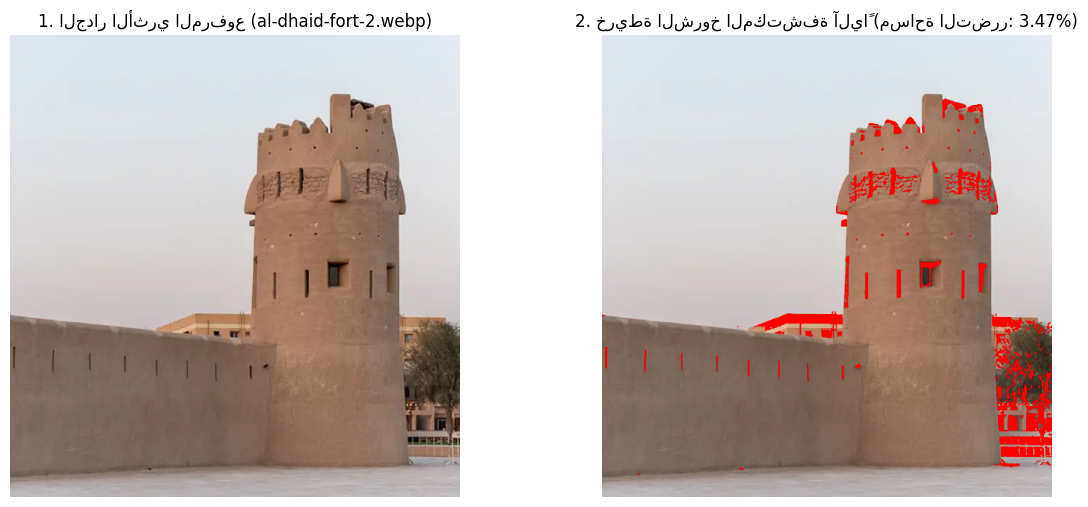


🚨 جاري إعداد التقرير الإنشائي المعتمد وفق معايير مشروع EAMENA الدولي...

📄 تقرير الصيانة الوقائية وإدارة المخاطر الإنشائية:
**هيئة الشارقة للآثار**  
**إدارة ترميم وصيانة المواقع الأثرية والمباني التاريخية**

---

### **تقرير تقييم الحالة والمخاطر الإنشائية (Structural Condition Assessment Report)**

* **اسم الموقع:** حصن/برج أثري (طراز العمارة الطينية التقليدية بالشارقة)
* **الموضوع:** تحليل الحالة الإنشائية وتأثير التضرر السطحي المرصود بنسبة **3.47%**
* **تاريخ التقييم:** أكتوبر 2023

---

### **1. التشخيص المورفولوجي (Morphological Diagnosis):**

بناءً على المعاينة البصرية والتحليل الرقمي للمناطق المحددة باللون الأحمر (خريطة الشروخ والتلف السطحي)، تم تصنيف مظاهر التلف إلى ما يلي:

* **تآكل وتفتت سطحي ناجم عن الرطوبة والأملاح (Chemical & Physical Weathering):**
  يظهر التلف بشكل رئيسي في الأجزاء العلوية من البرج (الشرفات والتتويج الجداري) والمناطق المحيطة بفتحات المرامي والشبابيك. يعود ذلك إلى عوامل التجوية، والرطوبة النسبية المرتفعة المميزة لبيئة الشارقة، وتراكم الأملاح التي تؤدي إ

In [1]:
# ==============================================================================
# المحور الرابع: الرصد الإنشائي للشروخ وتوليد تقارير الصيانة الوقائية (رفع صورة مخصصة)
# النموذج المستخدم: gemini-3.5-flash
# ==============================================================================

# 1. تثبيت المكتبات
!pip install -q google-genai opencv-python-headless matplotlib pillow arabic-reshaper python-bidi

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import getpass
from google.colab import files
from google import genai
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# 2. إعداد مفتاح API
if "GEMINI_API_KEY" not in os.environ:
    try:
        from google.colab import userdata
        api_key = userdata.get('GEMINI_API_KEY')
    except:
        api_key = getpass.getpass("🔑 أدخل مفتاح Gemini API: ")
    os.environ["GEMINI_API_KEY"] = api_key

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# 3. رفع صورة الجدار أو المبنى التاريخي
print("📤 يرجى رفع صورة الجدار التاريخي المصاب بالتصدعات أو التآكل:")
uploaded = files.upload()

if not uploaded:
    print("❌ لم يتم رفع أي ملف.")
else:
    file_name = next(iter(uploaded))
    wall_pil = Image.open(BytesIO(uploaded[file_name])).convert('RGB')
    wall_np = np.array(wall_pil)

    # 4. الرؤية الحاسوبية: عزل الشروخ وحساب النسبة المئوية للضرر
    gray_wall = cv2.cvtColor(wall_np, cv2.COLOR_RGB2GRAY)

    # تطبيق مرشح Blackhat لعزل التصدعات الداكنة والشقوق
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray_wall, cv2.MORPH_BLACKHAT, kernel)

    # عتبة تكيفية لفصل الشقوق
    _, crack_mask = cv2.threshold(blackhat, 30, 255, cv2.THRESH_BINARY)

    total_pixels = crack_mask.size
    damaged_pixels = cv2.countNonZero(crack_mask)
    damage_percentage = round((damaged_pixels / total_pixels) * 100, 2)

    # تمييز الشروخ باللون الأحمر
    crack_overlay = wall_np.copy()
    crack_overlay[crack_mask == 255] = [255, 0, 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(wall_np)
    axes[0].set_title(fix_arabic_text(f"1. الجدار الأثري المرفوع ({file_name})"))
    axes[0].axis('off')

    axes[1].imshow(crack_overlay)
    axes[1].set_title(fix_arabic_text(f"2. خريطة الشروخ المكتشفة آلياً (مساحة التضرر: {damage_percentage}%)"))
    axes[1].axis('off')
    plt.show()

    # 5. تقرير المخاطر والصيانة التنبؤية بواسطة gemini-3.5-flash
    print("\n🚨 جاري إعداد التقرير الإنشائي المعتمد وفق معايير مشروع EAMENA الدولي...")

    overlay_pil = Image.fromarray(crack_overlay)

    prompt = f"""
    بصفتك مهندس ترميم وصيانة المواقع الأثرية بهيئة الشارقة للآثار:
    حلل صورة الجدار المرفقة وخريطة الشروخ المستخرجة آلياً بنسبة تضرر سطحي {damage_percentage}%:
    أعد تقرير تقييم حالة ومخاطر إنشائية (Structural Condition Assessment) بصيغة Markdown يتضمن:
    1. التشخيص المورفولوجي:
       - تحديد نوع الشروخ (شروخ إجهاد إنشائي، شروخ حرارية، أو تفتت ناجم عن الرطوبة والأملاح).
    2. تصنيف درجة الخطورة والاستجابة:
       - [أخضر: مستقر] أو [أصفر: مراقبة فنائية مستمرة] أو [أحمر: تدخل هندسي عاجل].
    3. خطة التدخل الوقائي الموصى بها لفريق الترميم بالهيئة لحماية المنشأة من تفاقم الأضرار.
    """

    response_report = client.models.generate_content(
        model='gemini-3.5-flash',
        contents=[overlay_pil, prompt]
    )

    print("\n" + "="*70)
    print("📄 تقرير الصيانة الوقائية وإدارة المخاطر الإنشائية:")
    print("="*70)
    print(response_report.text)